# 03 — Explore data quality

A pre-cleaning inspection of three contrasting sensors to motivate the cleaning rules in NB04. Three sensors are chosen to represent different quality profiles:

- **SL001 Sunnyview Terrace** — long, healthy record spanning the full study period
- **SL026 Richmond Avenue** — continuous record with mid-range quality
- **SL030 Tingley Shire Road** — short record (dropped offline April 2023); illustrates data sparsity

Scatter and time-series plots subsample every 20th reading to keep render time under a second without losing the visible pattern.

In [27]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from src.config import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

samples = ["SL001_Sunnyview_Terrace", "SL026", "SL030"]

dfs = {}
for s in samples:
    dfs[s] = pd.read_parquet(PROCESSED / f"{s}.parquet")
    print(f"{s}: {len(dfs[s]):,} rows, "
          f"{dfs[s][DATE_COL].min()} -> {dfs[s][DATE_COL].max()}")

disp = lambda s: s.replace("_", " ")   # for figure titles only

SL001_Sunnyview_Terrace: 1,038,078 rows, 2022-03-07 18:37:08+00:00 -> 2026-02-19 18:57:20+00:00
SL026: 972,136 rows, 2022-03-25 14:31:32+00:00 -> 2026-08-23 23:59:33+00:00
SL030: 12,491 rows, 2022-03-25 14:40:07+00:00 -> 2023-04-08 23:50:21+00:00


### PM2.5 value-range summary

Byrne et al. (2024) quote the PMS5003 as having an effective range of
0–500 µg/m³ and a maximum range of 1000. Only the maximum is a hard physical
limit, so `MAX_PLAUSIBLE = 1000` is what NB04 uses to flag a reading as
impossible; the counts below show how much data sits in the 500–1000 band that
is retained but outside the range the manufacturer claims accuracy for.

In [28]:
for s, df in dfs.items():
    a = df[PM_A]
    print(f"\n=== {s} ===")
    print(f"  min: {a.min():.1f}   max: {a.max():.1f}   median: {a.median():.1f}")
    print(f"  negatives: {(a < 0).sum():,}")
    print(f"  exactly zero: {(a == 0).sum():,}")
    print(f"  above {EFFECTIVE_MAX} µg/m³ (outside effective range): {(a > EFFECTIVE_MAX).sum():,}")
    print(f"  above {MAX_PLAUSIBLE} µg/m³ (impossible, flagged in NB04): {(a > MAX_PLAUSIBLE).sum():,}")
    print(f"  NaN: {a.isna().sum():,}")


=== SL001_Sunnyview_Terrace ===
  min: 0.0   max: 3402.1   median: 2.9
  negatives: 0
  exactly zero: 323,439
  above 500 µg/m³ (outside effective range): 173,246
  above 1000 µg/m³ (impossible, flagged in NB04): 173,197
  NaN: 0

=== SL026 ===
  min: 0.0   max: 409.5   median: 1.9
  negatives: 0
  exactly zero: 297,973
  above 500 µg/m³ (outside effective range): 0
  above 1000 µg/m³ (impossible, flagged in NB04): 0
  NaN: 0

=== SL030 ===
  min: 0.0   max: 72.6   median: 0.1
  negatives: 0
  exactly zero: 6,048
  above 500 µg/m³ (outside effective range): 0
  above 1000 µg/m³ (impossible, flagged in NB04): 0
  NaN: 0


### What the out-of-range readings actually are

SL001 alone holds over 170,000 readings above the maximum range, and several
sensors reach almost exactly the same ceiling. If those values were a genuine
measurement they would take a spread of values; if they are a saturated or
stuck channel they will pile up on a handful. This decides whether the ceiling
flag is removing a physical impossibility or a specific hardware failure, and
it is the evidence behind the flag in NB04.

In [29]:
for s, df in dfs.items():
    hi = df.loc[df[PM_A] > MAX_PLAUSIBLE, PM_A]
    print(f"=== {s} ===  {len(hi):,} readings above {MAX_PLAUSIBLE} µg/m³")
    if len(hi):
        print(f"  distinct values: {hi.nunique():,}   "
              f"most common: {hi.value_counts().head(3).to_dict()}")
        # A stuck channel keeps the OTHER channel free to report normal air.
        both = ((df[PM_A] > MAX_PLAUSIBLE) & (df[PM_B] > MAX_PLAUSIBLE)).sum()
        print(f"  of these, both channels above the ceiling: {both:,} "
              f"({100 * both / len(hi):.1f}%)")

=== SL001_Sunnyview_Terrace ===  173,197 readings above 1000 µg/m³
  distinct values: 5,671   most common: {3330.6: 1544, 3329.9: 1504, 3329.4: 1501}
  of these, both channels above the ceiling: 3 (0.0%)
=== SL026 ===  0 readings above 1000 µg/m³
=== SL030 ===  0 readings above 1000 µg/m³


### Figure 1 — PM2.5 frequency distributions

Channel A readings clipped at 200 µg/m³ on a log-frequency scale. The right-skew is typical of PM2.5 in UK urban settings; the log axis makes low-frequency high-concentration events visible. This is orientation rather than a result, so it is an appendix figure.

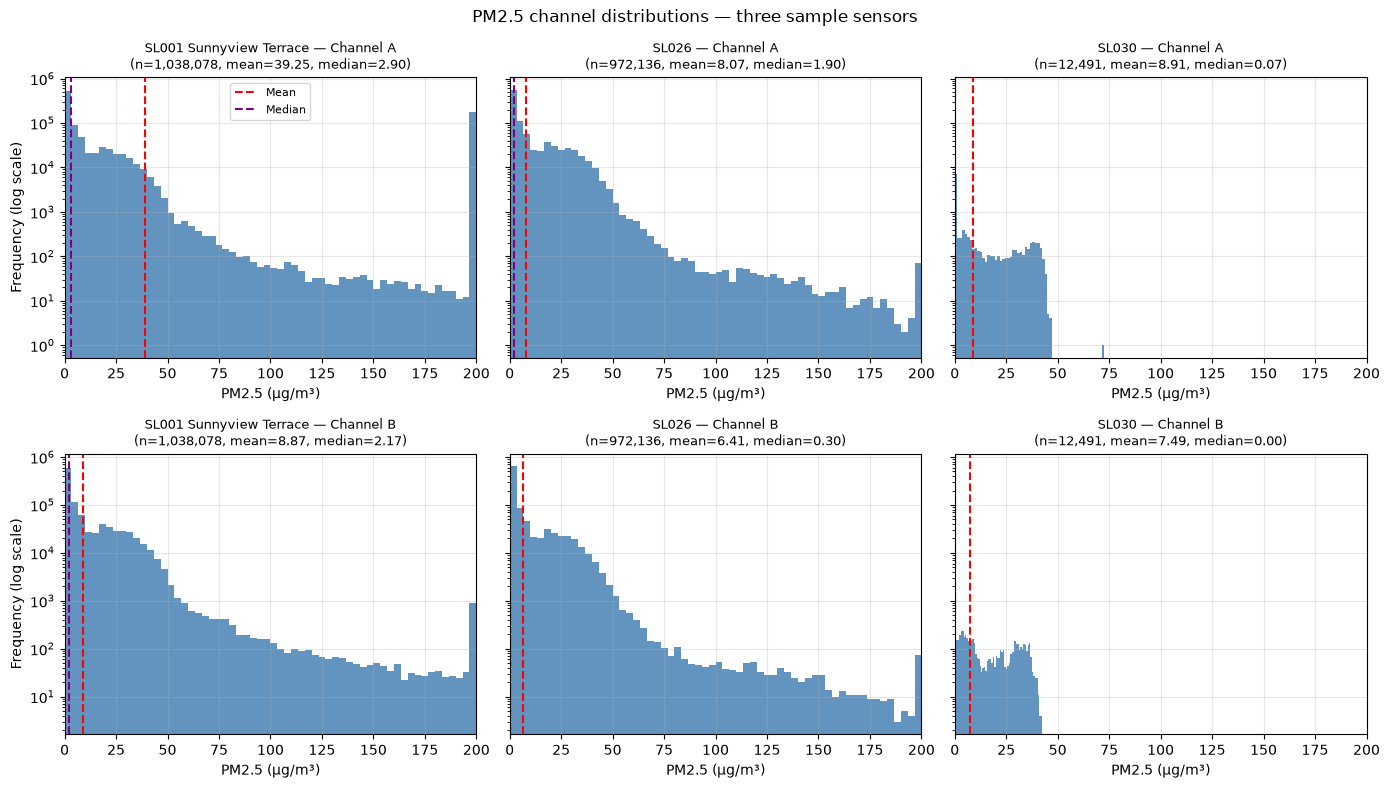

In [32]:
fig, axes = plt.subplots(2, len(samples), figsize=(14, 8), sharey="row")

for col, (s, df) in enumerate(dfs.items()):
    for row, channel in enumerate([PM_A, PM_B]):
        ax = axes[row, col]

        # Keep valid values within the plotted range
        values = df[channel].clip(0, 200).dropna()

        # Distribution
        ax.hist(
            values, bins=60, color="steelblue",
            edgecolor="none", alpha=0.85
        )

        # Mean and median
        ax.axvline(values.mean(), color="red",
                   linestyle="--", lw=1.5, label="Mean")
        ax.axvline(values.median(), color="purple",
                   linestyle="--", lw=1.5, label="Median")

        ax.set_yscale("log")
        ax.set_xlim(0, 200)
        ax.set_xlabel("PM2.5 (µg/m³)")
        ax.grid(alpha=0.3)

        # Sensor name and summary statistics
        ax.set_title(
            f"{disp(s)} — Channel {'A' if row == 0 else 'B'}\n"
            f"(n={len(values):,}, mean={values.mean():.2f}, "
            f"median={values.median():.2f})",
            fontsize=9
        )

        if col == 0:
            ax.set_ylabel("Frequency (log scale)")

axes[0, 0].legend(fontsize=8)

fig.suptitle(
    "PM2.5 channel distributions — three sample sensors",
    fontsize=12
)

plt.tight_layout()
plt.savefig(
    Figures / "03_pm25_channel_histograms.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

In [33]:
for s, df in dfs.items():
    print(
        f"{disp(s)}: "
        f"Channel A n = {df[PM_A].notna().sum():,}, "
        f"Channel B n = {df[PM_B].notna().sum():,}"
    )

SL001 Sunnyview Terrace: Channel A n = 1,038,078, Channel B n = 1,038,078
SL026: Channel A n = 972,136, Channel B n = 972,136
SL030: Channel A n = 12,491, Channel B n = 12,491


### Figure 2 — A/B channel agreement

A healthy PA-II sensor shows channels A and B tracking the 1:1 diagonal closely. Scatter around the diagonal or systematic offset indicates instrument degradation. Points are coloured by date to reveal whether agreement worsens over time. Every 20th reading is plotted to keep render time fast without changing the visible pattern.

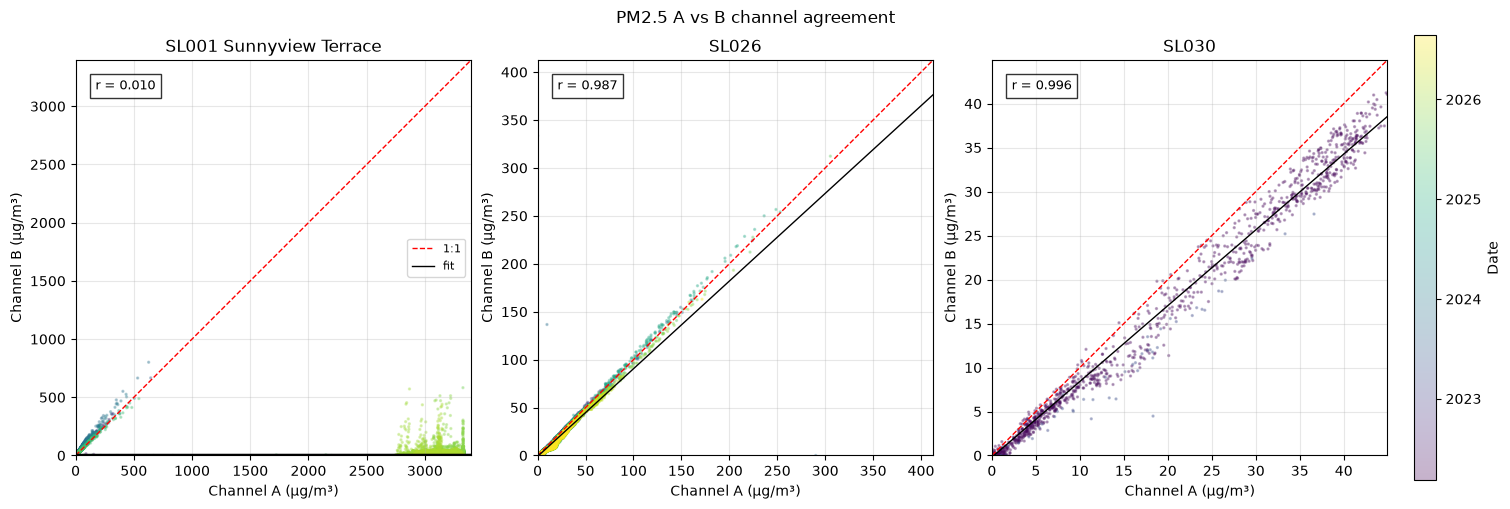

In [31]:
date_min = min(df[DATE_COL].min() for df in dfs.values())
date_max = max(df[DATE_COL].max() for df in dfs.values())
vmin, vmax = mdates.date2num(date_min), mdates.date2num(date_max)

fig, axes = plt.subplots(1, len(samples), figsize=(15, 5), constrained_layout=True)

for ax, (s, df) in zip(axes, dfs.items()):
    sub = df[[DATE_COL, PM_A, PM_B]].dropna().iloc[::5]  # every 5th row for speed
    hi  = max(sub[PM_A].max(), sub[PM_B].max())

    sc = ax.scatter(sub[PM_A], sub[PM_B],
                    c=mdates.date2num(sub[DATE_COL]),
                    cmap="viridis", s=2, alpha=0.3, vmin=vmin, vmax=vmax)

    ax.plot([0, hi], [0, hi], "r--", lw=1, label="1:1")

    slope, intercept = np.polyfit(sub[PM_A], sub[PM_B], 1)
    ax.plot([0, hi], [intercept, slope * hi + intercept], "k-", lw=1, label="fit")

    r = sub[[PM_A, PM_B]].corr().iloc[0, 1]
    ax.text(0.05, 0.95, f"r = {r:.3f}", transform=ax.transAxes,
            va="top", fontsize=9, bbox=dict(facecolor="white", alpha=0.8))

    ax.set(xlim=(0, hi), ylim=(0, hi), aspect="equal",
           title=disp(s), xlabel="Channel A (µg/m³)", ylabel="Channel B (µg/m³)")
    ax.grid(alpha=0.3)

axes[0].legend(fontsize=8)
cbar = fig.colorbar(sc, ax=axes, pad=0.02)
cbar.set_label("Date")
cbar.ax.yaxis.set_major_locator(mdates.YearLocator())
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("PM2.5 A vs B channel agreement", fontsize=12)
plt.savefig(Figures / "03_channel_agreement.png", dpi=200, bbox_inches="tight")
plt.show()

### Figure 3 — Raw time series, channels A and B

The full record for each sensor, clipped at 200 µg/m³ so extreme spikes do not compress normal variation. Every 5th reading is plotted (one point per ~10 min), which preserves visible spikes while keeping render time fast.

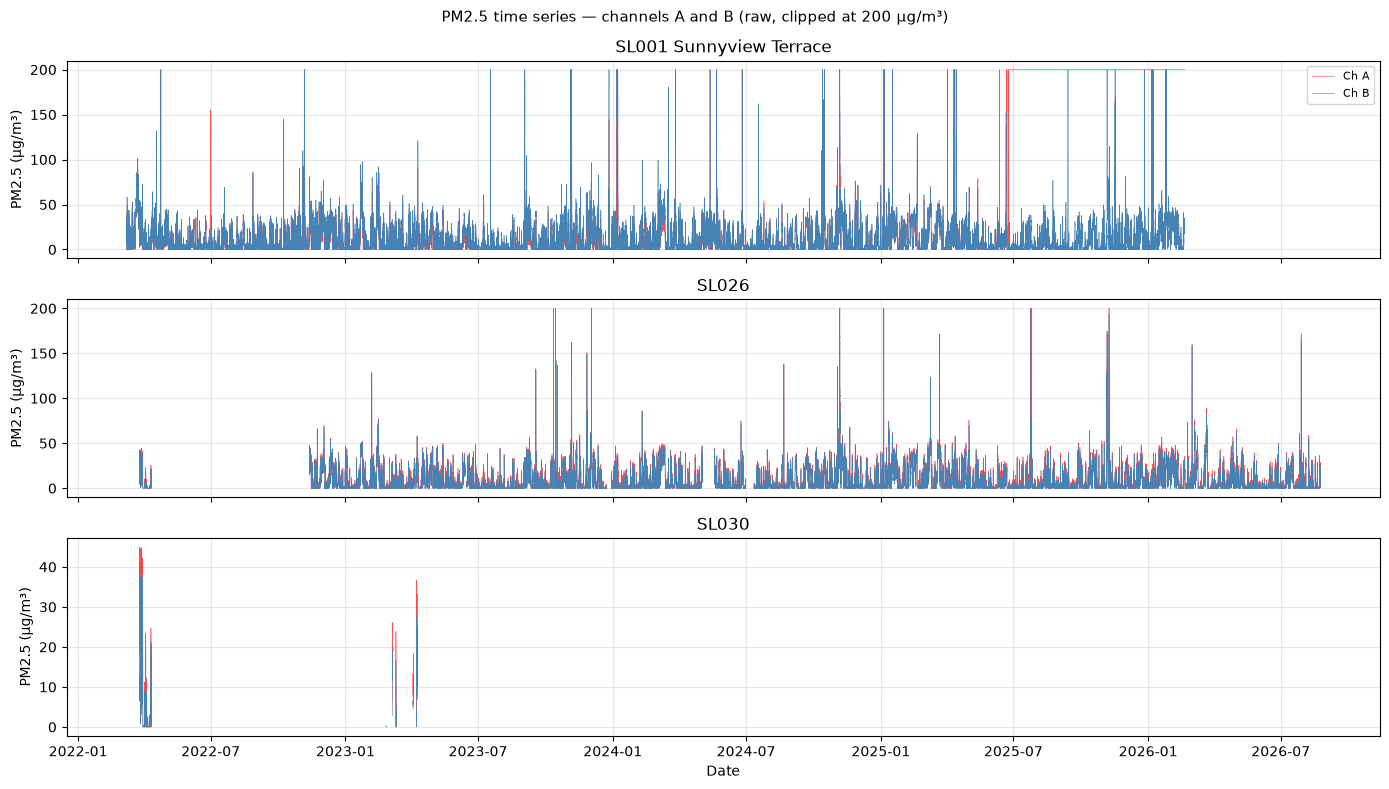

In [24]:
fig, axes = plt.subplots(len(samples), 1, figsize=(14, 8), sharex=True)

for ax, (s, df) in zip(axes, dfs.items()):
    sub = df.sort_values(DATE_COL).iloc[::5].copy()  # every 5th row for speed
    # Break the line across real offline stretches (>1 day, the same
    # threshold already used above to count them) so a genuine gap in the
    # data reads as a gap, not a straight line drawn across it.
    gap_days = sub[DATE_COL].diff().dt.total_seconds() / 86400
    a = sub[PM_A].clip(upper=200).where(gap_days.fillna(0) <= 1)
    b = sub[PM_B].clip(upper=200).where(gap_days.fillna(0) <= 1)
    ax.plot(sub[DATE_COL], a, lw=0.4, alpha=0.7, label="Ch A", color="red")
    ax.plot(sub[DATE_COL], b, lw=0.4, label="Ch B", color="steelblue")
    ax.set_ylabel("PM2.5 (µg/m³)")
    ax.set_title(disp(s))
    ax.grid(alpha=0.3)

axes[0].legend(fontsize=8)
axes[-1].set_xlabel("Date")
fig.suptitle("PM2.5 time series — channels A and B (raw, clipped at 200 µg/m³)", fontsize=11)
plt.tight_layout()
plt.savefig(Figures / "03_timeseries_AB.png", dpi=200, bbox_inches="tight")
plt.show()

### Time gaps between readings

Gaps longer than 10 minutes indicate missed readings. Gaps longer than one day mark offline stretches that will appear as missing values in the cleaned data.

In [25]:
for s, df in dfs.items():
    gaps = df[DATE_COL].diff().dt.total_seconds() / 60
    print(f"\n=== {s} ===")
    print(f"  median gap: {gaps.median():.1f} min  (expected ~2)")
    print(f"  gaps > 10 min: {(gaps > 10).sum():,}")
    print(f"  gaps > 1 day:  {(gaps > 1440).sum():,}  (offline stretches)")


=== SL001_Sunnyview_Terrace ===
  median gap: 2.0 min  (expected ~2)
  gaps > 10 min: 61
  gaps > 1 day:  1  (offline stretches)

=== SL026 ===
  median gap: 2.0 min  (expected ~2)
  gaps > 10 min: 180
  gaps > 1 day:  5  (offline stretches)

=== SL030 ===
  median gap: 2.0 min  (expected ~2)
  gaps > 10 min: 118
  gaps > 1 day:  7  (offline stretches)


### Temperature and humidity completeness

The Barkjohn humidity correction (NB04) requires relative humidity. Sensors with high RH missingness produce fewer corrected readings, reducing the pool available for CSI computation in NB05.

In [26]:
for s, df in dfs.items():
    print(f"{s}: Temp missing {df[TEMP_COL].isna().mean()*100:.1f}%,  "
          f"RH missing {df[RH_COL].isna().mean()*100:.1f}%")

SL001_Sunnyview_Terrace: Temp missing 23.5%,  RH missing 23.5%
SL026: Temp missing 0.0%,  RH missing 0.0%
SL030: Temp missing 0.0%,  RH missing 0.0%
